In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata, re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)

sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Usando la nueva variale respuesta

Creamos una nueva variable respuesta que se alinea a los datos y objetivos previamente establecidos, Dadas las características de las personas y los hogares (educación, estado civil, roles en el hogar, decisiones, urbanidad, matrimonios), queremos predecir si su combinación de VIF y divorcios lo ubica en: Conflicto visible, Violencia atrapada, Resolución legal, o Baja conflictividad.

Esto nos ayuda a categorizar si los departamento se encuentran dentro de dinamicas poco saluidables en donde los conflictos y los divorcios son la consucuencia de diversos factores

# 1. Creacion de el dataset

Este dataset nos ayuda a condensar la informacion para la variable respuesta a la que estamos apuntando en esta creamos una variable **categorica** llamada regimen en donde las dinamicas de violencia y divorcio lleva a esas instancias

In [6]:
# ============================================================
# DATASET ENFOQUE B: Cuatro Regímenes VIF × Divorcios
# ============================================================

def slugify(v):
    if not isinstance(v, str): return ''
    n = unicodedata.normalize('NFKD', v)
    s = "".join(ch for ch in n if not unicodedata.combining(ch)).lower()
    return re.sub(r'[^a-z0-9]+', '_', s).strip('_')

print("1. Cargando datasets...")
df_panel    = pd.read_csv('../Datos/Procesados/panel_departamento_anio.csv')
df_hogares  = pd.read_csv('../Datos/Poblacion/hogares_decisiones.csv',
                          encoding='latin-1', thousands=',')
df_economia = pd.read_csv('../Datos/Poblacion/economia_empleo.csv',
                          encoding='latin-1', thousands=',')
df_civil    = pd.read_csv('../Datos/Poblacion/estado_civil.csv')
df_edu      = pd.read_csv('../Datos/Poblacion/nivel_educativo.csv')
df_pob      = pd.read_csv('../Datos/Poblacion/poblacion_total.csv')

print("2. Normalizando claves geográficas...")
for df in [df_panel, df_hogares, df_economia, df_civil, df_edu, df_pob]:
    for col in ['departamento', 'Departamento']:
        if col in df.columns:
            df['key'] = df[col].apply(slugify)
            break

print("3. Feature engineering censal...")
sup = df_edu['Superior_Licenciatura'] + df_edu.get('Superior_Maestria_Doc', 0)
df_edu['pct_educacion_superior'] = (sup / df_edu['Poblacion_4_mas']) * 100

df_civil['pct_uniones_hecho'] = (df_civil['Unido'] / df_civil['Población_10_mas']) * 100
df_civil['pct_casados']       = (df_civil['Casado'] / df_civil['Población_10_mas']) * 100

df_hogares['pct_decision_mujer']  = (df_hogares['decision_mujer']  / df_hogares['total_de_hogares']) * 100
df_hogares['pct_decision_hombre'] = (df_hogares['decision_hombre'] / df_hogares['total_de_hogares']) * 100

pea_total = df_economia['pea_ocupados'] + df_economia['pea_cesantes'] + df_economia['pea_aspirantes']
df_economia['tasa_desempleo']        = ((df_economia['pea_cesantes'] + df_economia['pea_aspirantes']) / pea_total) * 100
df_economia['tasa_quehaceres_hogar'] = (df_economia['pei_quehaceres_hogar'] / df_economia['poblacion_15_mas']) * 100

df_pob = df_pob.rename(columns={'Población total censada': 'poblacion_total'})

print("4. Filtrando panel 2013-2022 (2023 no tiene divorcios)...")
df = df_panel[(df_panel['anio'] >= 2013) & (df_panel['anio'] <= 2022)].copy()

print("5. Merge con datos censales...")
df_master = df.merge(df_pob[['key', 'poblacion_total']], on='key', how='left')
df_master = df_master.merge(df_hogares[['key', 'pct_decision_mujer', 'pct_decision_hombre']], on='key', how='left')
df_master = df_master.merge(df_economia[['key', 'tasa_desempleo', 'tasa_quehaceres_hogar']], on='key', how='left')
df_master = df_master.merge(df_civil[['key', 'pct_uniones_hecho', 'pct_casados']], on='key', how='left')
df_master = df_master.merge(df_edu[['key', 'pct_educacion_superior']], on='key', how='left')

print("6. Calculando tasas temporales...")
df_master['tasa_vif_total']    = (df_master['vif_total']       / df_master['poblacion_total']) * 10000
df_master['tasa_divorcios_10k'] = (df_master['divorcios_total'] / df_master['poblacion_total']) * 10000

print("7. Creando TARGET: Cuatro regímenes por medianas ANUALES...")
df_master['mediana_vif_anio'] = df_master.groupby('anio')['tasa_vif_total'].transform('median')
df_master['mediana_div_anio'] = df_master.groupby('anio')['tasa_divorcios_10k'].transform('median')
df_master['vif_alto'] = df_master['tasa_vif_total']    >= df_master['mediana_vif_anio']
df_master['div_alto'] = df_master['tasa_divorcios_10k'] >= df_master['mediana_div_anio']

def clasificar_regimen(row):
    if row['vif_alto'] and row['div_alto']:
        return 'Conflicto_visible'
    elif row['vif_alto'] and not row['div_alto']:
        return 'Violencia_atrapada'
    elif not row['vif_alto'] and row['div_alto']:
        return 'Resolucion_legal'
    else:
        return 'Baja_conflictividad'

df_master['regimen'] = df_master.apply(clasificar_regimen, axis=1)

# Limpieza
df_master = df_master.dropna(subset=['pct_uniones_hecho', 'pct_educacion_superior',
                                      'tasa_desempleo', 'pct_decision_mujer',
                                      'tasa_divorcios_10k'])

print(f"\nDataset final: {df_master.shape}")
print("\n=== DISTRIBUCIÓN DEL TARGET ===")
print(df_master['regimen'].value_counts())
print(f"\nEn porcentaje:")
print((df_master['regimen'].value_counts(normalize=True) * 100).round(1))

print("\n=== PRIMERAS FILAS ===")
display(df_master[['departamento', 'anio', 'tasa_vif_total',
                    'tasa_divorcios_10k', 'vif_alto', 'div_alto', 'regimen']].head(10))

# ============================================================
# EXPORTAR DATASET A CSV
# ============================================================
columnas_finales = [
    'departamento', 'anio', 'poblacion_total',
    'tasa_vif_total', 'tasa_divorcios_10k',
    'vif_alto', 'div_alto',
    'pct_educacion_superior', 'pct_uniones_hecho', 'pct_casados',
    'pct_decision_mujer', 'pct_decision_hombre',
    'tasa_desempleo', 'tasa_quehaceres_hogar',
    'regimen'
]

df_export = df_master[columnas_finales].copy()
ruta_export = '../Datos/Procesados/dataset_enfoque_regimenes.csv'
df_export.to_csv(ruta_export, index=False, encoding='utf-8-sig')
print(f"\nArchivo exportado: {ruta_export}")
print(f"   Dimensiones: {df_export.shape}")

1. Cargando datasets...
2. Normalizando claves geográficas...
3. Feature engineering censal...
4. Filtrando panel 2013-2022 (2023 no tiene divorcios)...
5. Merge con datos censales...
6. Calculando tasas temporales...
7. Creando TARGET: Cuatro regímenes por medianas ANUALES...

Dataset final: (220, 136)

=== DISTRIBUCIÓN DEL TARGET ===
regimen
Conflicto_visible      68
Baja_conflictividad    68
Violencia_atrapada     42
Resolucion_legal       42
Name: count, dtype: int64

En porcentaje:
regimen
Conflicto_visible      30.9
Baja_conflictividad    30.9
Violencia_atrapada     19.1
Resolucion_legal       19.1
Name: proportion, dtype: float64

=== PRIMERAS FILAS ===


,departamento,anio,tasa_vif_total,tasa_divorcios_10k,vif_alto,div_alto,regimen
0,Alta Verapaz,2013,27.398320,0.979393,True,False,Violencia_atrapada
1,Baja Verapaz,2013,39.201806,3.272382,True,True,Conflicto_visible
2,Chimaltenango,2013,27.834797,1.039339,True,False,Violencia_atrapada
3,Chiquimula,2013,10.576708,2.096067,False,False,Baja_conflictividad
4,El Progreso,2013,63.748358,4.076272,True,True,Conflicto_visible
5,Escuintla,2013,10.638574,2.086797,False,False,Baja_conflictividad
6,Guatemala,2013,21.156977,5.979939,False,True,Resolucion_legal
7,Huehuetenango,2013,15.802930,1.067766,False,False,Baja_conflictividad
8,Izabal,2013,19.917394,3.009631,False,True,Resolucion_legal
9,Jalapa,2013,24.378651,2.857784,False,True,Resolucion_legal



Archivo exportado: ../Datos/Procesados/dataset_enfoque_regimenes.csv
   Dimensiones: (220, 15)


Las bases que usamos para crear la nueva variable respuesta fueron las siguientes:
- Calculamos la media tanto para la taza de divorcios como para la taza de VIF
- Si un departamento tenia su taza de VIF por abajo de la media lo clasificabamos como abajo de la media, de igual forma por arriba de la media
- Si un departamento tenia su taza de divorcios por abajo de la media lo clasificabamos como abajo de la media, de igual forma por arriba de la media
- Los clasificamos en 4 partes
    - VIF encima de la media, Divorcios por encima de la media
    - VIF encima de la media, Divorcios por abajo de la media
    - VIF abajo de la media, Divorcios por encima de la media
    - VIF abajo de la media, Divorcios por abajo de la media

# Preparacion de variables

Preparamos nuestras variables predictoras  en donde tomamos el 75% de los datos para train y el 25% para test

In [7]:
# ============================================================
# VARIABLES PREDICTORAS (X) y TARGET (y)
# ============================================================

features = [
    'pct_educacion_superior',
    'pct_uniones_hecho',
    'pct_casados',
    'pct_decision_mujer',
    'pct_decision_hombre',
    'tasa_desempleo',
    'tasa_quehaceres_hogar'
]

# Rellenar nulos marginales
df_master[features] = df_master[features].fillna(df_master[features].median())

# Encoding del target
le = LabelEncoder()
df_master['Target'] = le.fit_transform(df_master['regimen'])
clases_target = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Clases del target:\n{clases_target}\n")

# Split + Scaling
X = df_master[features]
y = df_master['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Entrenamiento: {X_train_scaled.shape}")
print(f"Prueba:        {X_test_scaled.shape}")
print("\nPipeline listo para modelado.")

Clases del target:
{'Baja_conflictividad': np.int64(0), 'Conflicto_visible': np.int64(1), 'Resolucion_legal': np.int64(2), 'Violencia_atrapada': np.int64(3)}

Entrenamiento: (165, 7)
Prueba:        (55, 7)

Pipeline listo para modelado.


Arbol de decision

In [8]:
param_grid_dt = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_dt,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_dt.fit(X_train_scaled, y_train)

# ============================================================
# EXTRAER LOS TOP 3 MODELOS DEL GRID
# ============================================================
resultados_cv = pd.DataFrame(grid_dt.cv_results_)
top3 = resultados_cv.sort_values('rank_test_score').head(3)

# Guardar los 3 modelos entrenados
top3_modelos = []
top3_params = []
top3_scores = []

for idx, fila in top3.iterrows():
    params = fila['params']
    score_cv = fila['mean_test_score']
    
    modelo = DecisionTreeClassifier(random_state=42, class_weight='balanced', **params)
    modelo.fit(X_train_scaled, y_train)
    
    top3_modelos.append(modelo)
    top3_params.append(params)
    top3_scores.append(score_cv)

print("=" * 70)
print("TOP 3 COMBINACIONES DE HIPERPARÁMETROS — ÁRBOL DE DECISIÓN")
print("=" * 70)
for i, (params, score) in enumerate(zip(top3_params, top3_scores), start=1):
    print(f"\n Ranking #{i}")
    print(f"   F1 Macro (CV): {score:.4f}")
    print(f"   Parámetros: {params}")

print("\n" + "=" * 70)
print("Los 3 modelos están guardados en: top3_modelos, top3_params, top3_scores")
print("=" * 70)

TOP 3 COMBINACIONES DE HIPERPARÁMETROS — ÁRBOL DE DECISIÓN

 Ranking #1
   F1 Macro (CV): 0.7694
   Parámetros: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}

 Ranking #2
   F1 Macro (CV): 0.7694
   Parámetros: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 10}

 Ranking #3
   F1 Macro (CV): 0.7627
   Parámetros: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}

Los 3 modelos están guardados en: top3_modelos, top3_params, top3_scores


EVALUANDO MODELO RANKING #3
Parámetros: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}
F1 Macro (CV): 0.7627

MÉTRICAS GLOBALES — ÁRBOL DE DECISIÓN (Ranking #3)
Accuracy:          0.8000
F1 Score (macro):  0.7946
F1 Score (weight): 0.8025
Precision (macro): 0.8011
Recall (macro):    0.7936

REPORTE POR CLASE
                     precision    recall  f1-score   support

Baja_conflictividad       0.83      0.88      0.86        17
  Conflicto_visible       0.87      0.76      0.81        17
   Resolucion_legal       0.62      0.73      0.67        11
 Violencia_atrapada       0.89      0.80      0.84        10

           accuracy                           0.80        55
          macro avg       0.80      0.79      0.79        55
       weighted avg       0.81      0.80      0.80        55



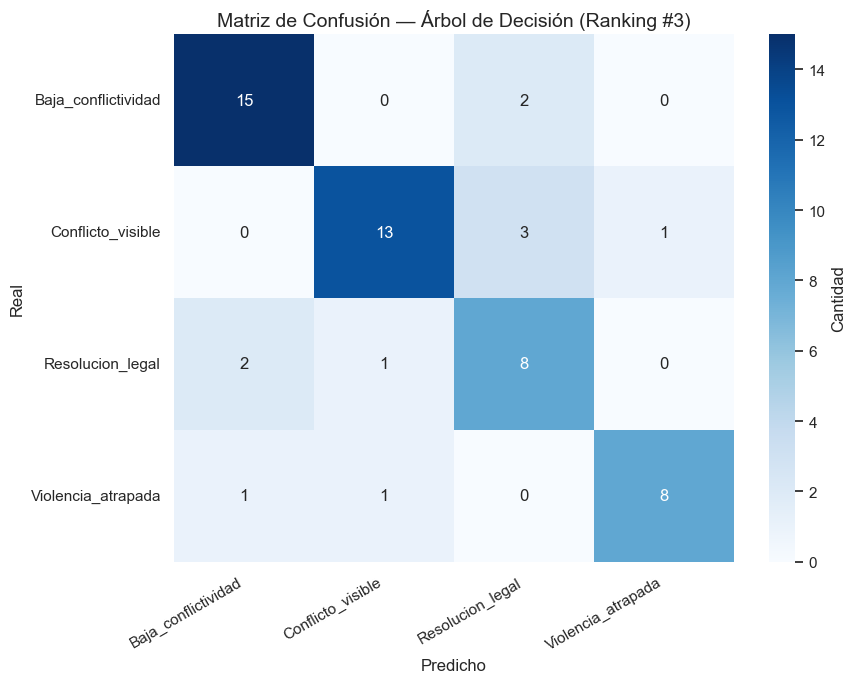

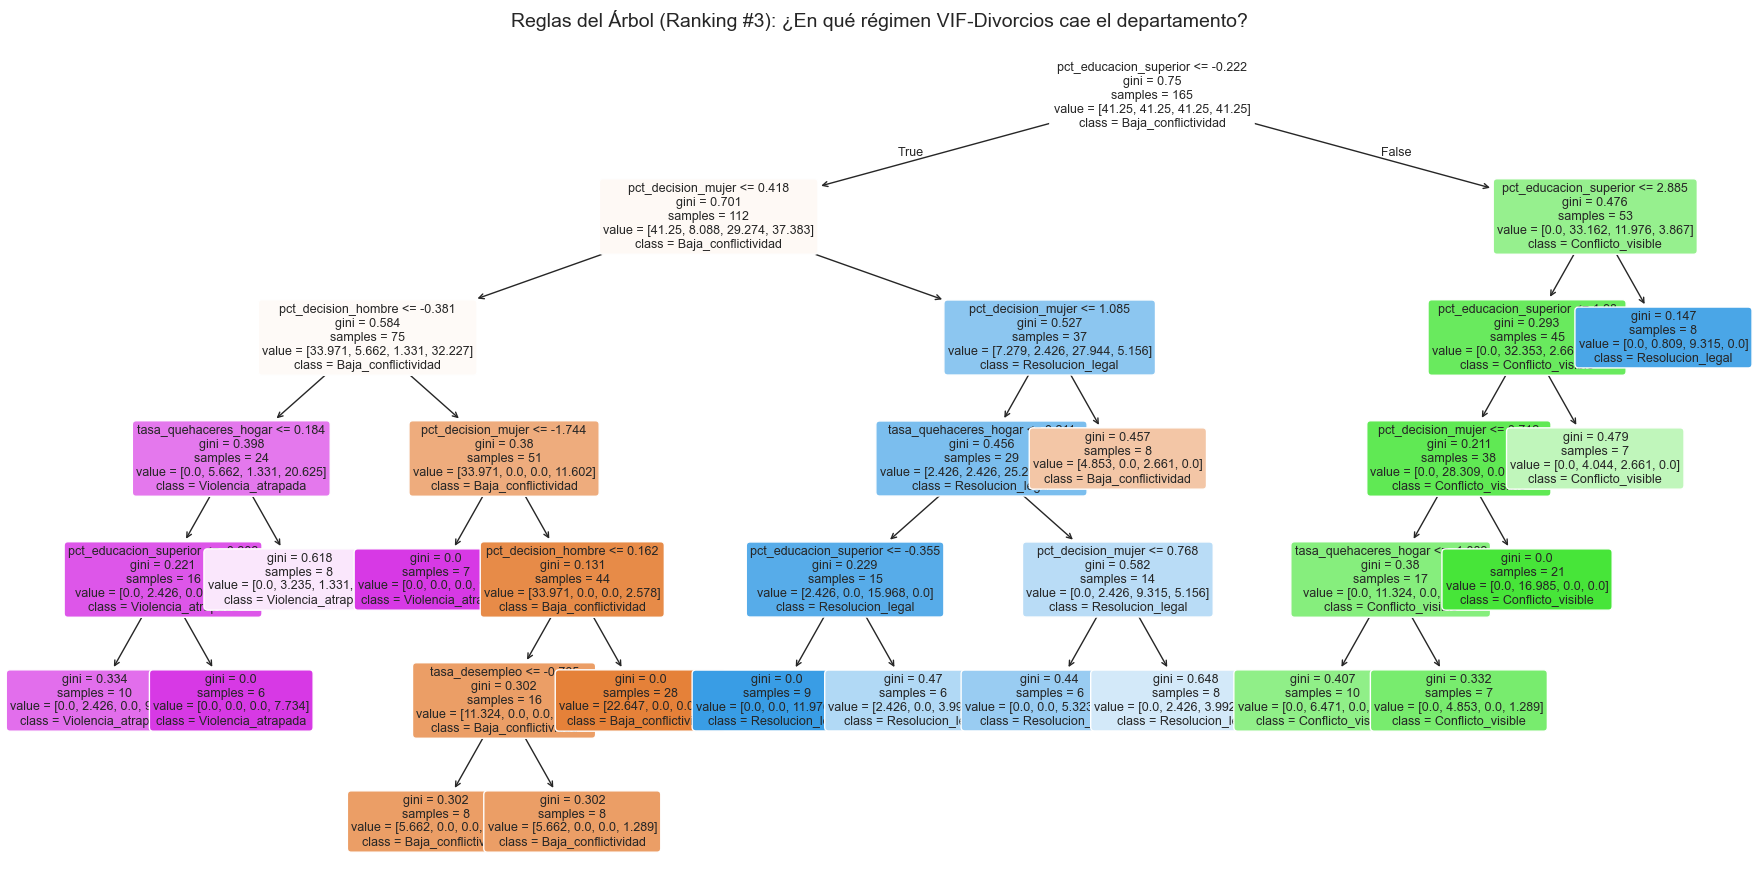

In [9]:
# ============================================================
# EVALUAR UN MODELO ESPECÍFICO DEL TOP 3
# ============================================================
# 0 = Mejor modelo (ranking #1)
# 1 = Segundo mejor modelo (ranking #2)
# 2 = Tercer mejor modelo (ranking #3)

POSICION = 2 

dt = top3_modelos[POSICION]
params_actuales = top3_params[POSICION]
score_cv_actual = top3_scores[POSICION]
y_pred_dt = dt.predict(X_test_scaled)

print("=" * 70)
print(f"EVALUANDO MODELO RANKING #{POSICION + 1}")
print("=" * 70)
print(f"Parámetros: {params_actuales}")
print(f"F1 Macro (CV): {score_cv_actual:.4f}\n")

# Métricas globales
print("=" * 60)
print(f"MÉTRICAS GLOBALES — ÁRBOL DE DECISIÓN (Ranking #{POSICION + 1})")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score (macro):  {f1_score(y_test, y_pred_dt, average='macro'):.4f}")
print(f"F1 Score (weight): {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_dt, average='macro', zero_division=0):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred_dt, average='macro'):.4f}")

print("\n" + "=" * 60)
print("REPORTE POR CLASE")
print("=" * 60)
print(classification_report(y_test, y_pred_dt, target_names=le.classes_, zero_division=0))


cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Cantidad'})
plt.title(f'Matriz de Confusión — Árbol de Decisión (Ranking #{POSICION + 1})', fontsize=14)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


plt.figure(figsize=(22, 11))
plot_tree(dt, feature_names=features, class_names=le.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title(f"Reglas del Árbol (Ranking #{POSICION + 1}): ¿En qué régimen VIF-Divorcios cae el departamento?", fontsize=14)
plt.show()

El árbol de decisión alcanzó un F1 macro de 0.79 y un accuracy de 80% en el conjunto de prueba, un desempeño significativamente superior al de un clasificador trivial (31%) y muy superior a lo obtenido con el enfoque original, donde el F1 macro real era de apenas 0.33 por el colapso del target. El modelo distingue correctamente los cuatro regímenes de conflicto familiar, y el análisis de la estructura del árbol revela que la variable más discriminante es el porcentaje de población con educación superior, seguida por las decisiones dentro del hogar (particularmente la proporción de hogares donde la mujer decide). Estos hallazgos respaldan la hipótesis de que el acceso a la justicia y la autonomía femenina son factores estructurales clave para explicar los distintos tipos de dinámicas de violencia intrafamiliar en el territorio guatemalteco. 

Random forest

In [10]:
# ============================================================
# TUNING: RANDOM FOREST — GUARDAR LOS TOP 3 MODELOS
# ============================================================
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_rf.fit(X_train_scaled, y_train)

# ============================================================
# EXTRAER LOS TOP 3 MODELOS DEL GRID
# ============================================================
resultados_cv_rf = pd.DataFrame(grid_rf.cv_results_)
top3_rf_df = resultados_cv_rf.sort_values('rank_test_score').head(3)

top3_rf_modelos = []
top3_rf_params = []
top3_rf_scores = []

for idx, fila in top3_rf_df.iterrows():
    params = fila['params']
    score_cv = fila['mean_test_score']
    
    modelo = RandomForestClassifier(random_state=42, class_weight='balanced', **params)
    modelo.fit(X_train_scaled, y_train)
    
    top3_rf_modelos.append(modelo)
    top3_rf_params.append(params)
    top3_rf_scores.append(score_cv)

print("=" * 70)
print("TOP 3 COMBINACIONES DE HIPERPARÁMETROS — RANDOM FOREST")
print("=" * 70)
for i, (params, score) in enumerate(zip(top3_rf_params, top3_rf_scores), start=1):
    print(f"\nRanking #{i}")
    print(f"   F1 Macro (CV): {score:.4f}")
    print(f"   Parámetros: {params}")

print("\n" + "=" * 70)
print("Los 3 modelos están guardados en: top3_rf_modelos, top3_rf_params, top3_rf_scores")
print("=" * 70)

TOP 3 COMBINACIONES DE HIPERPARÁMETROS — RANDOM FOREST

Ranking #1
   F1 Macro (CV): 0.7868
   Parámetros: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}

Ranking #2
   F1 Macro (CV): 0.7868
   Parámetros: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}

Ranking #3
   F1 Macro (CV): 0.7868
   Parámetros: {'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}

Los 3 modelos están guardados en: top3_rf_modelos, top3_rf_params, top3_rf_scores


EVALUANDO MODELO RANKING #3
Parámetros: {'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}
F1 Macro (CV): 0.7868

MÉTRICAS GLOBALES — RANDOM FOREST (Ranking #3)
Accuracy:          0.8000
F1 Score (macro):  0.7946
F1 Score (weight): 0.8025
Precision (macro): 0.8011
Recall (macro):    0.7936

REPORTE POR CLASE
                     precision    recall  f1-score   support

Baja_conflictividad       0.83      0.88      0.86        17
  Conflicto_visible       0.87      0.76      0.81        17
   Resolucion_legal       0.62      0.73      0.67        11
 Violencia_atrapada       0.89      0.80      0.84        10

           accuracy                           0.80        55
          macro avg       0.80      0.79      0.79        55
       weighted avg       0.81      0.80      0.80        55



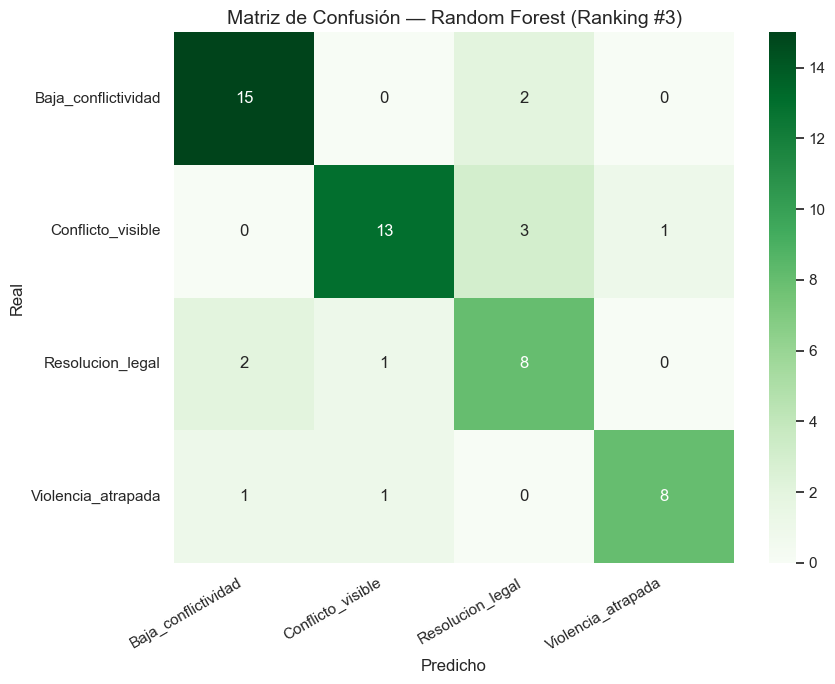

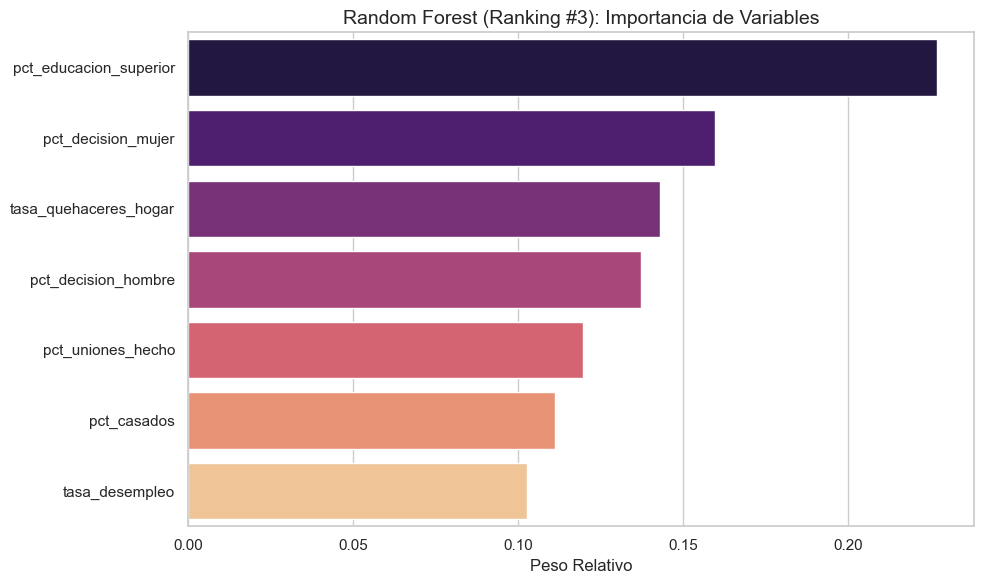


Ranking de importancia (Modelo #3):
              Variable  Importancia
pct_educacion_superior       0.2268
    pct_decision_mujer       0.1595
 tasa_quehaceres_hogar       0.1431
   pct_decision_hombre       0.1372
     pct_uniones_hecho       0.1195
           pct_casados       0.1111
        tasa_desempleo       0.1028


In [11]:
# ============================================================
# EVALUAR UN MODELO ESPECÍFICO DEL TOP 3 — RANDOM FOREST
# ============================================================

# 0 = Mejor modelo (ranking #1)
# 1 = Segundo mejor modelo (ranking #2)
# 2 = Tercer mejor modelo (ranking #3)

POSICION = 2 

rf = top3_rf_modelos[POSICION]
params_actuales = top3_rf_params[POSICION]
score_cv_actual = top3_rf_scores[POSICION]
y_pred_rf = rf.predict(X_test_scaled)

print("=" * 70)
print(f"EVALUANDO MODELO RANKING #{POSICION + 1}")
print("=" * 70)
print(f"Parámetros: {params_actuales}")
print(f"F1 Macro (CV): {score_cv_actual:.4f}\n")

# Métricas globales
print("=" * 60)
print(f"MÉTRICAS GLOBALES — RANDOM FOREST (Ranking #{POSICION + 1})")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score (macro):  {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"F1 Score (weight): {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_rf, average='macro', zero_division=0):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred_rf, average='macro'):.4f}")

print("\n" + "=" * 60)
print("REPORTE POR CLASE")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusión — Random Forest (Ranking #{POSICION + 1})', fontsize=14)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Importancia de variables
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(features)[indices], palette="magma")
plt.title(f"Random Forest (Ranking #{POSICION + 1}): Importancia de Variables", fontsize=14)
plt.xlabel("Peso Relativo")
plt.tight_layout()
plt.show()

df_imp = pd.DataFrame({
    'Variable': np.array(features)[indices],
    'Importancia': importances[indices]
}).round(4)
print(f"\nRanking de importancia (Modelo #{POSICION + 1}):")
print(df_imp.to_string(index=False))

Logistica

In [12]:
# ============================================================
# TUNING: REGRESIÓN LOGÍSTICA — GUARDAR LOS TOP 3 MODELOS
# ============================================================
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

# ============================================================
# EXTRAER LOS TOP 3 MODELOS DEL GRID
# ============================================================
resultados_cv_lr = pd.DataFrame(grid_lr.cv_results_)
top3_lr_df = resultados_cv_lr.sort_values('rank_test_score').head(3)

top3_lr_modelos = []
top3_lr_params = []
top3_lr_scores = []

for idx, fila in top3_lr_df.iterrows():
    params = fila['params']
    score_cv = fila['mean_test_score']
    
    modelo = LogisticRegression(random_state=42, max_iter=1000,
                                 class_weight='balanced', **params)
    modelo.fit(X_train_scaled, y_train)
    
    top3_lr_modelos.append(modelo)
    top3_lr_params.append(params)
    top3_lr_scores.append(score_cv)

print("=" * 70)
print("TOP 3 COMBINACIONES DE HIPERPARÁMETROS — REGRESIÓN LOGÍSTICA")
print("=" * 70)
for i, (params, score) in enumerate(zip(top3_lr_params, top3_lr_scores), start=1):
    print(f"\nRanking #{i}")
    print(f"   F1 Macro (CV): {score:.4f}")
    print(f"   Parámetros: {params}")

print("\n" + "=" * 70)
print("Los 3 modelos están guardados en: top3_lr_modelos, top3_lr_params, top3_lr_scores")
print("=" * 70)

TOP 3 COMBINACIONES DE HIPERPARÁMETROS — REGRESIÓN LOGÍSTICA

Ranking #1
   F1 Macro (CV): 0.6796
   Parámetros: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

Ranking #2
   F1 Macro (CV): 0.6796
   Parámetros: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}

Ranking #3
   F1 Macro (CV): 0.6792
   Parámetros: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}

Los 3 modelos están guardados en: top3_lr_modelos, top3_lr_params, top3_lr_scores


EVALUANDO MODELO RANKING #3
Parámetros: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
F1 Macro (CV): 0.6792

MÉTRICAS GLOBALES — REGRESIÓN LOGÍSTICA (Ranking #3)
Accuracy:          0.7818
F1 Score (macro):  0.7832
F1 Score (weight): 0.7907
Precision (macro): 0.8275
Recall (macro):    0.7846

REPORTE POR CLASE
                     precision    recall  f1-score   support

Baja_conflictividad       0.94      0.88      0.91        17
  Conflicto_visible       0.85      0.65      0.73        17
   Resolucion_legal       0.53      0.91      0.67        11
 Violencia_atrapada       1.00      0.70      0.82        10

           accuracy                           0.78        55
          macro avg       0.83      0.78      0.78        55
       weighted avg       0.84      0.78      0.79        55



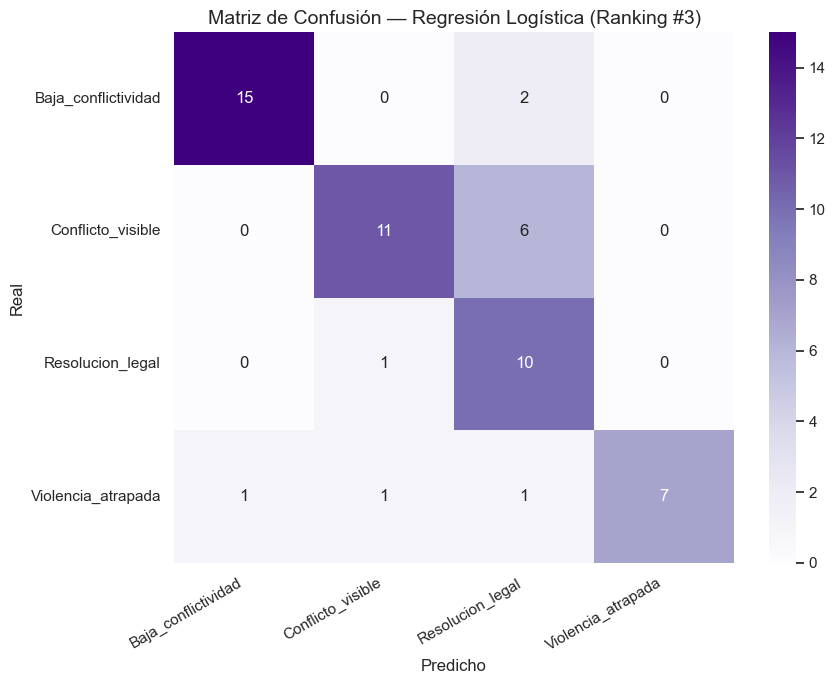


Shape de coeficientes: (4, 7)


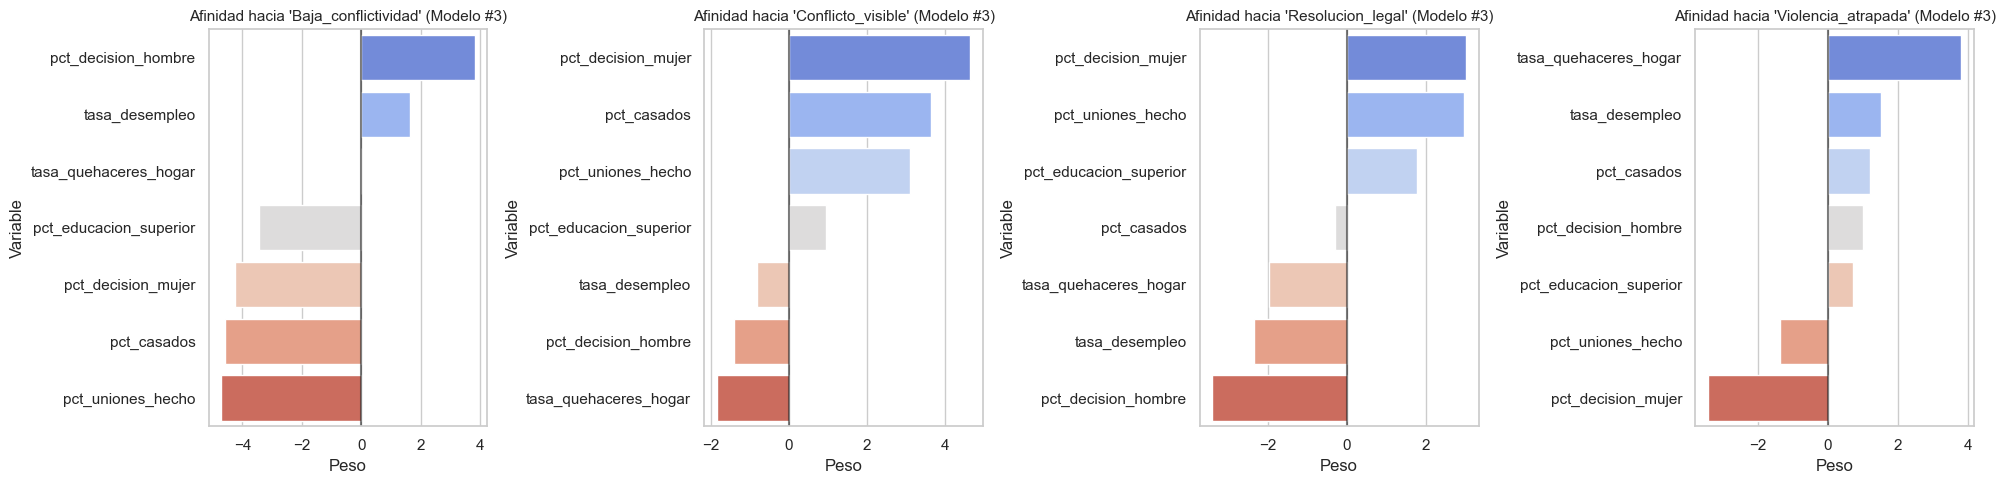


Tabla de coeficientes (Modelo #3):
              Clase  pct_educacion_superior  pct_uniones_hecho  pct_casados  pct_decision_mujer  pct_decision_hombre  tasa_desempleo  tasa_quehaceres_hogar
Baja_conflictividad                 -3.4533            -4.7055      -4.5723             -4.2436               3.8211          1.6423                 0.0068
  Conflicto_visible                  0.9556             3.1126       3.6507              4.6603              -1.4231         -0.8155                -1.8521
   Resolucion_legal                  1.7818             2.9593      -0.2953              3.0091              -3.3999         -2.3420                -1.9665
 Violencia_atrapada                  0.7160            -1.3664       1.2169             -3.4258               1.0019          1.5152                 3.8118


In [13]:
# ============================================================
# EVALUAR UN MODELO ESPECÍFICO DEL TOP 3 — REGRESIÓN LOGÍSTICA
# ============================================================
# 0 = Mejor modelo (ranking #1)
# 1 = Segundo mejor modelo (ranking #2)
# 2 = Tercer mejor modelo (ranking #3)

POSICION = 2   

log_reg = top3_lr_modelos[POSICION]
params_actuales = top3_lr_params[POSICION]
score_cv_actual = top3_lr_scores[POSICION]
y_pred_lr = log_reg.predict(X_test_scaled)

print("=" * 70)
print(f"EVALUANDO MODELO RANKING #{POSICION + 1}")
print("=" * 70)
print(f"Parámetros: {params_actuales}")
print(f"F1 Macro (CV): {score_cv_actual:.4f}\n")

# Métricas globales
print("=" * 60)
print(f"MÉTRICAS GLOBALES — REGRESIÓN LOGÍSTICA (Ranking #{POSICION + 1})")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score (macro):  {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"F1 Score (weight): {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_lr, average='macro', zero_division=0):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred_lr, average='macro'):.4f}")

print("\n" + "=" * 60)
print("REPORTE POR CLASE")
print("=" * 60)
print(classification_report(y_test, y_pred_lr, target_names=le.classes_, zero_division=0))

# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusión — Regresión Logística (Ranking #{POSICION + 1})', fontsize=14)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Coeficientes por clase
coef = log_reg.coef_
print(f"\nShape de coeficientes: {coef.shape}")

n_clases_coef = coef.shape[0]
clases_mostrar = le.classes_[:n_clases_coef]

fig, axes = plt.subplots(1, n_clases_coef, figsize=(5*n_clases_coef, 5))
if n_clases_coef == 1:
    axes = [axes]

for i, (ax, clase) in enumerate(zip(axes, clases_mostrar)):
    df_coef = pd.DataFrame({'Variable': features, 'Peso': coef[i]})
    df_coef = df_coef.sort_values(by='Peso', ascending=False)
    sns.barplot(data=df_coef, x='Peso', y='Variable', palette="coolwarm", ax=ax)
    ax.axvline(0, color='black', alpha=0.5)
    ax.set_title(f"Afinidad hacia '{clase}' (Modelo #{POSICION + 1})", fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nTabla de coeficientes (Modelo #{POSICION + 1}):")
df_coef_full = pd.DataFrame(coef, columns=features)
df_coef_full.insert(0, 'Clase', le.classes_[:coef.shape[0]])
print(df_coef_full.round(4).to_string(index=False))

## Support Vector Machine (SVM)

En esta sección se entrena y evalúa un modelo SVM con búsqueda de hiperparámetros para hacerlo comparable con Árbol, Random Forest y Regresión Logística.

Se usa validación cruzada con `f1_macro` para priorizar desempeño balanceado entre clases, y luego se evalúa en el conjunto de prueba con métricas y visualizaciones.

TOP 3 COMBINACIONES DE HIPERPARÁMETROS — SVM

Ranking #1
   F1 Macro (CV validación): 0.7600
   F1 Macro (CV entrenamiento): 0.7921
   Parámetros: {'svc__C': 0.1, 'svc__gamma': 1, 'svc__kernel': 'rbf'}

Ranking #2
   F1 Macro (CV validación): 0.7501
   F1 Macro (CV entrenamiento): 0.8120
   Parámetros: {'svc__C': 10, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}

Ranking #3
   F1 Macro (CV validación): 0.7377
   F1 Macro (CV entrenamiento): 0.7947
   Parámetros: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}

RUN SVM - Ranking #1
Parámetros: {'svc__C': 0.1, 'svc__gamma': 1, 'svc__kernel': 'rbf'}
F1 CV Train:      0.7921
F1 CV Validación: 0.7600 ± 0.0579
F1 Train Holdout: 0.8128
F1 Test:          0.7041
Accuracy Test:    0.7273
Gap CV:           0.0321
Gap Test:         0.1087
Diagnóstico:      Posible sobreajuste
Conclusión:       El modelo aprende muy bien entrenamiento pero cae en generalización (gap_cv=0.032, gap_test=0.109).

RUN SVM - Ranking #2
Parám

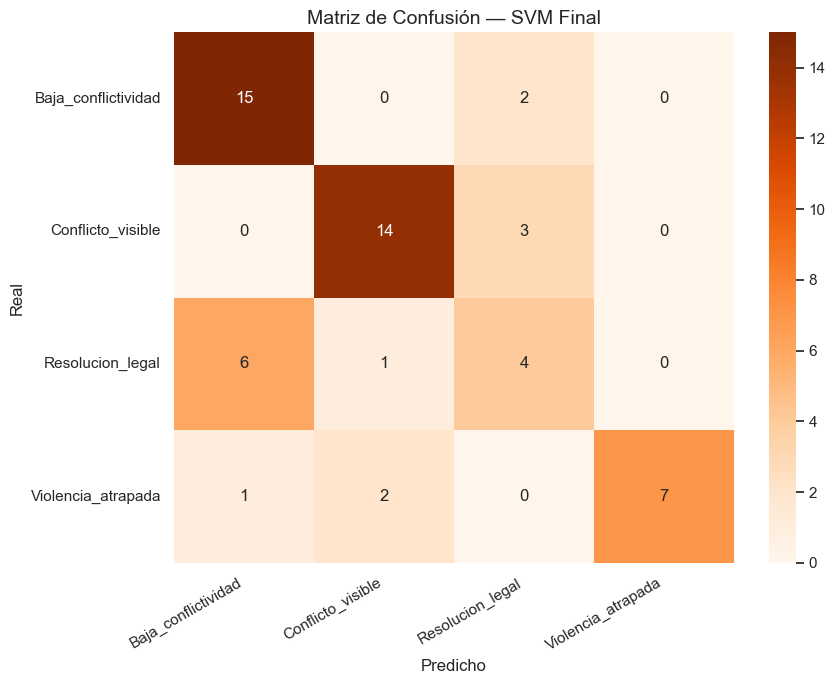

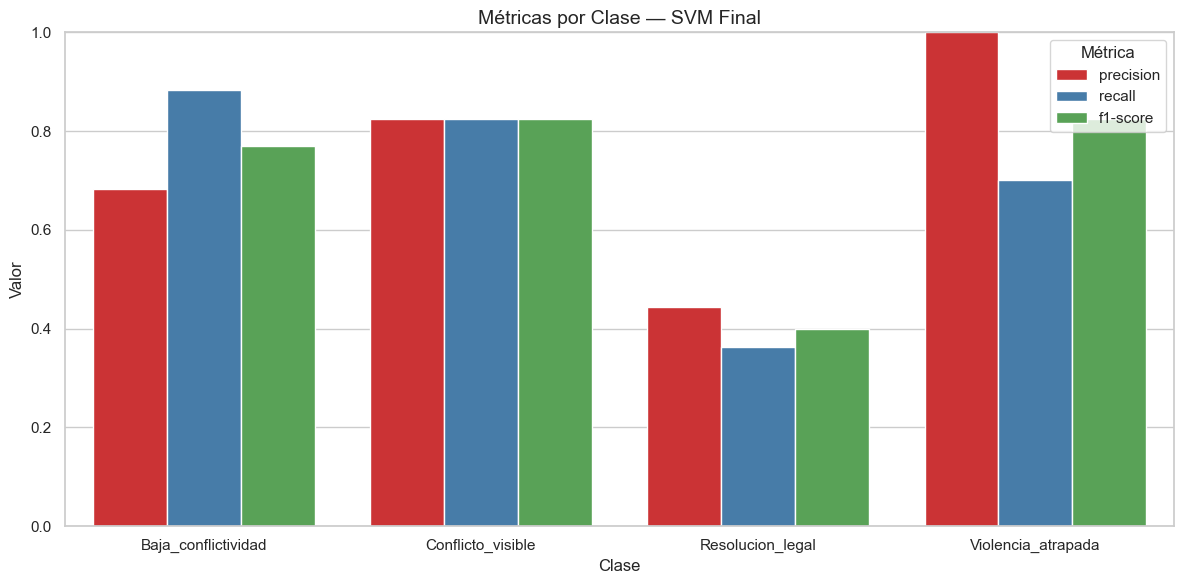

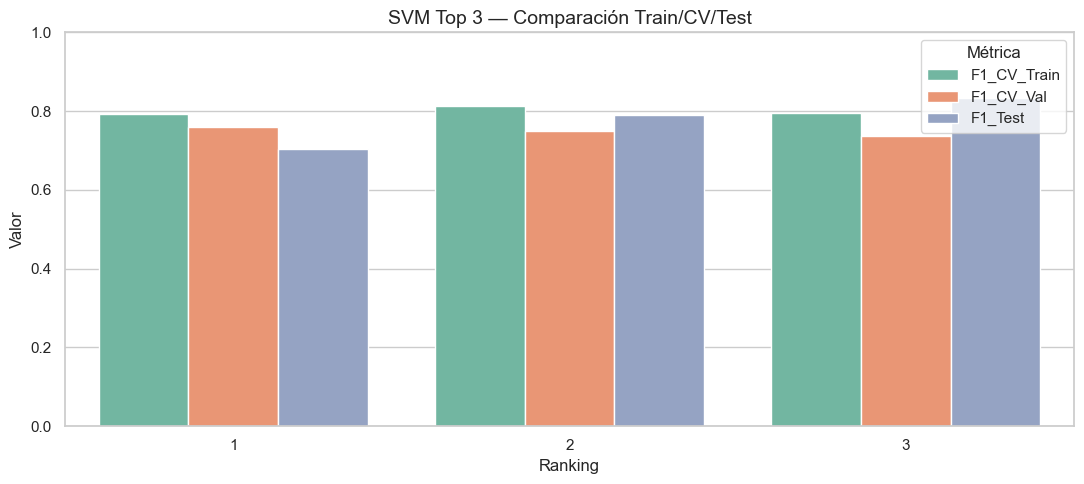

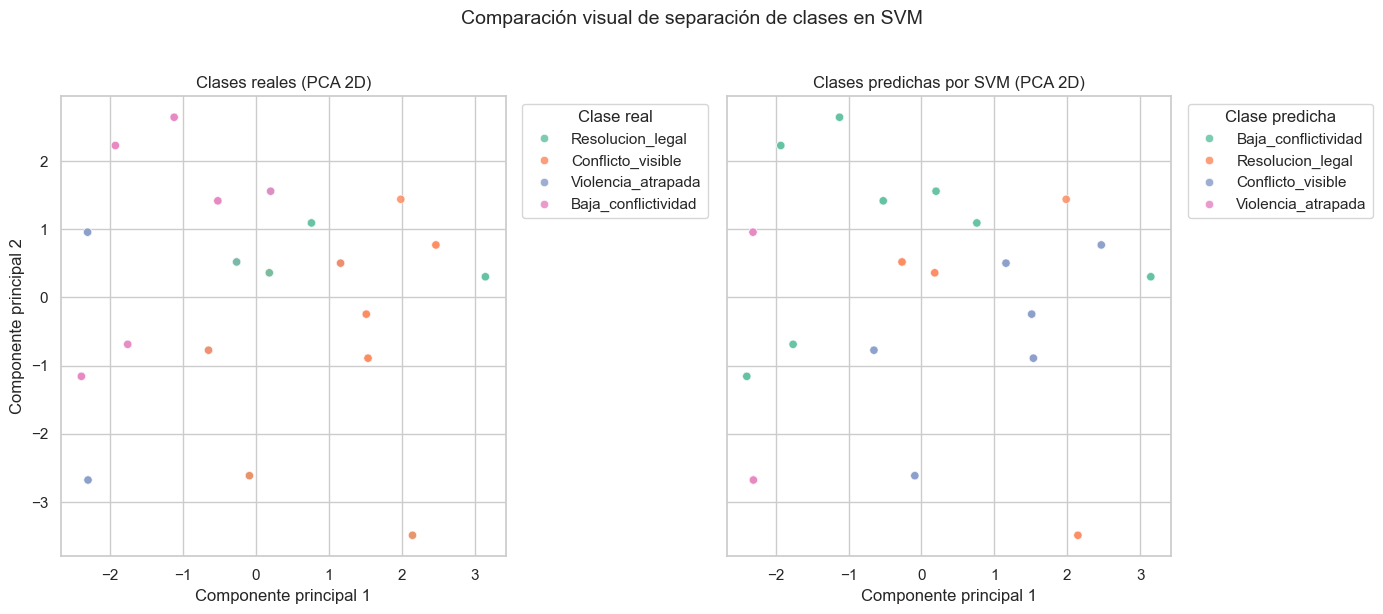


CONCLUSIÓN FINAL SVM
El mejor SVM muestra señales de sobreajuste. Se recomienda reducir complejidad (C/gamma) o ampliar datos.
F1 Macro de prueba: 0.7041 | Accuracy de prueba: 0.7273
Esta corrida queda lista para compararse con Árbol, Random Forest y Regresión Logística.


In [14]:
# ============================================================
# TUNING + VALIDACIÓN + DIAGNÓSTICO: SUPPORT VECTOR MACHINE
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

# Pipeline dedicado para SVM: preprocesamiento + modelo en un solo flujo
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(class_weight='balanced'))
])

# Búsqueda de hiperparámetros
param_grid_svm = [
    {'svc__kernel': ['linear'], 'svc__C': [0.1, 1, 5, 10, 20]},
    {'svc__kernel': ['rbf'], 'svc__C': [0.1, 1, 5, 10, 20], 'svc__gamma': ['scale', 0.01, 0.1, 1]},
    {'svc__kernel': ['poly'], 'svc__C': [0.1, 1, 5, 10], 'svc__degree': [2, 3, 4], 'svc__gamma': ['scale']}
 ]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)
grid_svm.fit(X_train, y_train)

# Extraer Top 3 configuraciones
resultados_cv_svm = pd.DataFrame(grid_svm.cv_results_)
top3_svm_df = resultados_cv_svm.sort_values('rank_test_score').head(3).copy()

print('=' * 75)
print('TOP 3 COMBINACIONES DE HIPERPARÁMETROS — SVM')
print('=' * 75)
for i, (_, fila) in enumerate(top3_svm_df.iterrows(), start=1):
    print(f"\nRanking #{i}")
    print(f"   F1 Macro (CV validación): {fila['mean_test_score']:.4f}")
    print(f"   F1 Macro (CV entrenamiento): {fila['mean_train_score']:.4f}")
    print(f"   Parámetros: {fila['params']}")

# ============================================================
# ANÁLISIS POR CADA RUN (TOP 3): desempeño + sobreajuste
# ============================================================
def diagnostico_modelo(train_cv_f1, val_cv_f1, train_holdout_f1, test_f1):
    gap_cv = train_cv_f1 - val_cv_f1
    gap_test = train_holdout_f1 - test_f1

    if gap_cv > 0.08 or gap_test > 0.08:
        estado = 'Posible sobreajuste'
        conclusion = (
            f"El modelo aprende muy bien entrenamiento pero cae en generalización "
            f"(gap_cv={gap_cv:.3f}, gap_test={gap_test:.3f})."
        )
    elif train_holdout_f1 < 0.60 and test_f1 < 0.60:
        estado = 'Posible subajuste'
        conclusion = (
            f"El desempeño es bajo tanto en entrenamiento como en prueba "
            f"(train={train_holdout_f1:.3f}, test={test_f1:.3f})."
        )
    else:
        estado = 'Generalización estable'
        conclusion = (
            f"No se observa sobreajuste fuerte; el modelo mantiene consistencia "
            f"entre entrenamiento y prueba (gap_test={gap_test:.3f})."
        )

    return estado, conclusion, gap_cv, gap_test

resumen_runs_svm = []

for i, (_, fila) in enumerate(top3_svm_df.iterrows(), start=1):
    params = fila['params']
    modelo_i = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(class_weight='balanced'))
    ])
    modelo_i.set_params(**params)

    # Validación cruzada específica para este run
    cv_i = cross_validate(
        modelo_i,
        X_train, y_train,
        cv=skf,
        scoring=['f1_macro', 'accuracy'],
        return_train_score=True,
        n_jobs=-1
    )

    train_cv_f1 = cv_i['train_f1_macro'].mean()
    val_cv_f1 = cv_i['test_f1_macro'].mean()
    val_cv_f1_std = cv_i['test_f1_macro'].std()

    # Ajuste en train y evaluación en test
    modelo_i.fit(X_train, y_train)
    y_pred_i = modelo_i.predict(X_test)

    train_holdout_f1 = f1_score(y_train, modelo_i.predict(X_train), average='macro')
    test_f1 = f1_score(y_test, y_pred_i, average='macro')
    test_acc = accuracy_score(y_test, y_pred_i)

    estado, conclusion, gap_cv, gap_test = diagnostico_modelo(
        train_cv_f1, val_cv_f1, train_holdout_f1, test_f1
    )

    score_generalizacion = val_cv_f1 - 0.5 * max(gap_cv, 0)

    resumen_runs_svm.append({
        'Ranking': i,
        'Parametros': params,
        'F1_CV_Train': train_cv_f1,
        'F1_CV_Val': val_cv_f1,
        'F1_CV_Val_STD': val_cv_f1_std,
        'F1_Train_Holdout': train_holdout_f1,
        'F1_Test': test_f1,
        'Accuracy_Test': test_acc,
        'Gap_CV': gap_cv,
        'Gap_Test': gap_test,
        'Estado': estado,
        'Score_Generalizacion': score_generalizacion
    })

    print('\n' + '=' * 75)
    print(f'RUN SVM - Ranking #{i}')
    print('=' * 75)
    print(f'Parámetros: {params}')
    print(f'F1 CV Train:      {train_cv_f1:.4f}')
    print(f'F1 CV Validación: {val_cv_f1:.4f} ± {val_cv_f1_std:.4f}')
    print(f'F1 Train Holdout: {train_holdout_f1:.4f}')
    print(f'F1 Test:          {test_f1:.4f}')
    print(f'Accuracy Test:    {test_acc:.4f}')
    print(f'Gap CV:           {gap_cv:.4f}')
    print(f'Gap Test:         {gap_test:.4f}')
    print(f'Diagnóstico:      {estado}')
    print(f'Conclusión:       {conclusion}')

df_runs_svm = pd.DataFrame(resumen_runs_svm).sort_values('Ranking').copy()

print('\n' + '=' * 75)
print('RESUMEN ANALÍTICO TOP 3 — SVM')
print('=' * 75)
print(df_runs_svm[['Ranking', 'F1_CV_Val', 'F1_CV_Val_STD', 'F1_Test', 'Accuracy_Test',
                   'Gap_CV', 'Gap_Test', 'Estado', 'Score_Generalizacion']].round(4).to_string(index=False))

# Selección final priorizando generalización
best_idx = df_runs_svm['Score_Generalizacion'].idxmax()
best_row = df_runs_svm.loc[best_idx]
POSICION = int(best_row['Ranking']) - 1

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(class_weight='balanced'))
])
svm.set_params(**best_row['Parametros'])
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print('\n' + '=' * 75)
print(f'MODELO SVM SELECCIONADO: Ranking #{int(best_row["Ranking"])}')
print('=' * 75)
print(f'Parámetros elegidos: {best_row["Parametros"]}')
print(f"Criterio: mayor Score_Generalizacion = {best_row['Score_Generalizacion']:.4f}")
print(f"Diagnóstico final: {best_row['Estado']}")

# ============================================================
# EVALUACIÓN DETALLADA DEL MODELO SVM FINAL
# ============================================================
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_macro_svm = f1_score(y_test, y_pred_svm, average='macro')
f1_weighted_svm = f1_score(y_test, y_pred_svm, average='weighted')
precision_macro_svm = precision_score(y_test, y_pred_svm, average='macro', zero_division=0)
recall_macro_svm = recall_score(y_test, y_pred_svm, average='macro')

print('\n' + '=' * 60)
print('MÉTRICAS GLOBALES — SVM FINAL')
print('=' * 60)
print(f'Accuracy:          {acc_svm:.4f}')
print(f'F1 Score (macro):  {f1_macro_svm:.4f}')
print(f'F1 Score (weight): {f1_weighted_svm:.4f}')
print(f'Precision (macro): {precision_macro_svm:.4f}')
print(f'Recall (macro):    {recall_macro_svm:.4f}')

print('\n' + '=' * 60)
print('REPORTE POR CLASE')
print('=' * 60)
print(classification_report(y_test, y_pred_svm, target_names=le.classes_, zero_division=0))

# Matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión — SVM Final', fontsize=14)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Gráfico: métricas por clase
report_dict = classification_report(
    y_test, y_pred_svm, target_names=le.classes_, zero_division=0, output_dict=True
)
metricas_clase = pd.DataFrame(report_dict).T.loc[le.classes_, ['precision', 'recall', 'f1-score']]
metricas_plot = metricas_clase.reset_index().rename(columns={'index': 'Clase'})
metricas_plot = metricas_plot.melt(id_vars='Clase', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(data=metricas_plot, x='Clase', y='Valor', hue='Métrica', palette='Set1')
plt.title('Métricas por Clase — SVM Final', fontsize=14)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Gráfico: estabilidad CV por run
cv_plot = df_runs_svm[['Ranking', 'F1_CV_Train', 'F1_CV_Val', 'F1_Test']].copy()
cv_plot = cv_plot.melt(id_vars='Ranking', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(11, 5))
sns.barplot(data=cv_plot, x='Ranking', y='Valor', hue='Métrica', palette='Set2')
plt.title('SVM Top 3 — Comparación Train/CV/Test', fontsize=14)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Visualización 2D (PCA) de clases reales vs predichas
from sklearn.decomposition import PCA

X_test_scaled_svm = svm.named_steps['scaler'].transform(X_test)
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test_scaled_svm)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
sns.scatterplot(
    x=X_test_pca[:, 0], y=X_test_pca[:, 1],
    hue=le.inverse_transform(y_test),
    palette='Set2', alpha=0.85, ax=axes[0]
 )
axes[0].set_title('Clases reales (PCA 2D)')
axes[0].set_xlabel('Componente principal 1')
axes[0].set_ylabel('Componente principal 2')
axes[0].legend(title='Clase real', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.scatterplot(
    x=X_test_pca[:, 0], y=X_test_pca[:, 1],
    hue=le.inverse_transform(y_pred_svm),
    palette='Set2', alpha=0.85, ax=axes[1]
 )
axes[1].set_title('Clases predichas por SVM (PCA 2D)')
axes[1].set_xlabel('Componente principal 1')
axes[1].set_ylabel('Componente principal 2')
axes[1].legend(title='Clase predicha', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('Comparación visual de separación de clases en SVM', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Conclusión final automática de la corrida SVM
print('\n' + '=' * 75)
print('CONCLUSIÓN FINAL SVM')
print('=' * 75)
if best_row['Estado'] == 'Posible sobreajuste':
    print('El mejor SVM muestra señales de sobreajuste. Se recomienda reducir complejidad (C/gamma) o ampliar datos.')
elif best_row['Estado'] == 'Posible subajuste':
    print('El SVM quedó corto de capacidad predictiva. Se recomienda ampliar búsqueda de hiperparámetros o nuevas variables.')
else:
    print('El SVM seleccionado muestra buena estabilidad entre entrenamiento, validación y prueba.')
print(f"F1 Macro de prueba: {f1_macro_svm:.4f} | Accuracy de prueba: {acc_svm:.4f}")
print('Esta corrida queda lista para compararse con Árbol, Random Forest y Regresión Logística.')

# Comparativa de los 4 modelos

COMPARATIVA DE MODELOS — ENFOQUE B (4 REGÍMENES)
             Modelo  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
              Árbol    0.8000    0.7946       0.8025           0.8011        0.7936
      Random Forest    0.8000    0.7946       0.8025           0.8011        0.7936
Regresión Logística    0.7818    0.7832       0.7907           0.8275        0.7846
                SVM    0.7273    0.7041       0.7220           0.7374        0.6924


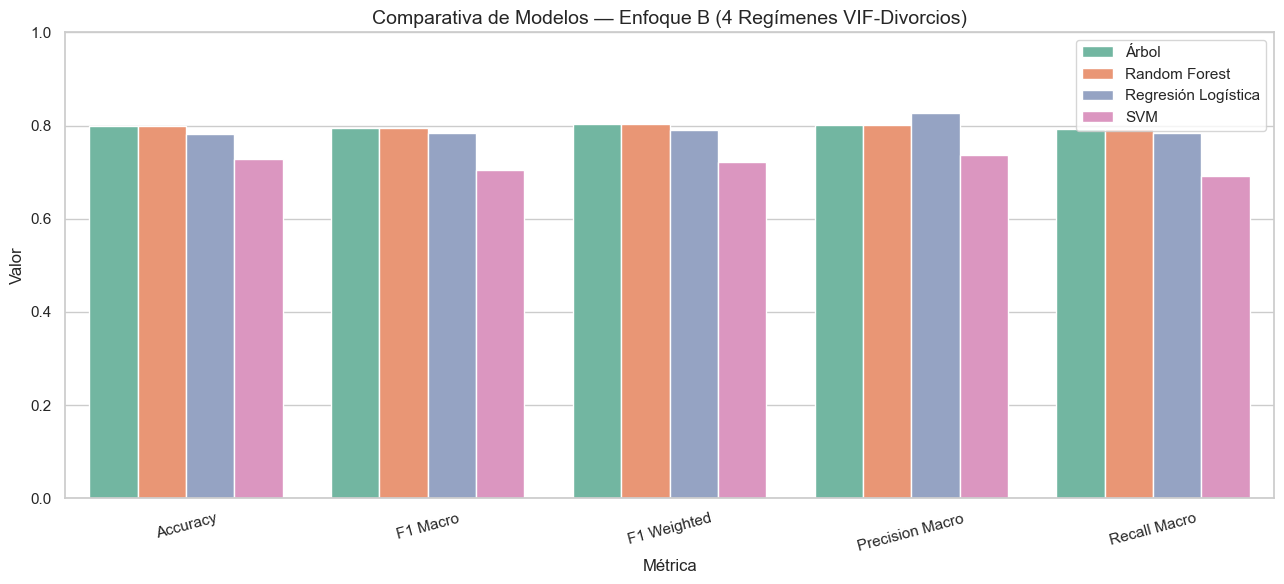

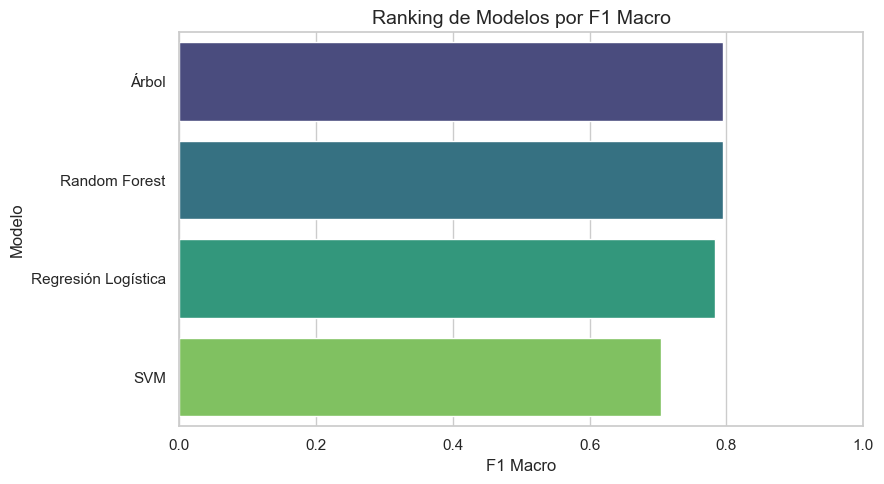

In [15]:
# ============================================================
# TABLA COMPARATIVA DE LOS 4 MODELOS
# ============================================================
resultados = pd.DataFrame({
    'Modelo': ['Árbol', 'Random Forest', 'Regresión Logística', 'SVM'],
    'Accuracy':        [accuracy_score(y_test, y_pred_dt),
                        accuracy_score(y_test, y_pred_rf),
                        accuracy_score(y_test, y_pred_lr),
                        accuracy_score(y_test, y_pred_svm)],
    'F1 Macro':        [f1_score(y_test, y_pred_dt, average='macro'),
                        f1_score(y_test, y_pred_rf, average='macro'),
                        f1_score(y_test, y_pred_lr, average='macro'),
                        f1_score(y_test, y_pred_svm, average='macro')],
    'F1 Weighted':     [f1_score(y_test, y_pred_dt, average='weighted'),
                        f1_score(y_test, y_pred_rf, average='weighted'),
                        f1_score(y_test, y_pred_lr, average='weighted'),
                        f1_score(y_test, y_pred_svm, average='weighted')],
    'Precision Macro': [precision_score(y_test, y_pred_dt, average='macro', zero_division=0),
                        precision_score(y_test, y_pred_rf, average='macro', zero_division=0),
                        precision_score(y_test, y_pred_lr, average='macro', zero_division=0),
                        precision_score(y_test, y_pred_svm, average='macro', zero_division=0)],
    'Recall Macro':    [recall_score(y_test, y_pred_dt, average='macro'),
                        recall_score(y_test, y_pred_rf, average='macro'),
                        recall_score(y_test, y_pred_lr, average='macro'),
                        recall_score(y_test, y_pred_svm, average='macro')]
}).round(4)

print('=' * 70)
print('COMPARATIVA DE MODELOS — ENFOQUE B (4 REGÍMENES)')
print('=' * 70)
print(resultados.to_string(index=False))

# Gráfico comparativo general
resultados_melt = resultados.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(13, 6))
sns.barplot(data=resultados_melt, x='Métrica', y='Valor', hue='Modelo', palette='Set2')
plt.title('Comparativa de Modelos — Enfoque B (4 Regímenes VIF-Divorcios)', fontsize=14)
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Gráfico de ranking por F1 Macro
resultados_f1 = resultados.sort_values('F1 Macro', ascending=False).copy()
plt.figure(figsize=(9, 5))
sns.barplot(data=resultados_f1, x='F1 Macro', y='Modelo', palette='viridis')
plt.title('Ranking de Modelos por F1 Macro', fontsize=14)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()